In [1]:
import os
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import seaborn as sns
from PIL import Image
from skimage import color, feature, exposure
from skimage.feature import hog, local_binary_pattern
from skimage.transform import resize
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import hashlib

np.random.seed(42)
torch.manual_seed(42)

In [2]:
from google.colab import drive

drive.mount('/content/drive')

# SET CLASSES AND THEIR LABELS
classes = ['glioma', 'meningioma', 'notumor', 'pituitary']
class_labels = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

# resize all images in preproc to 128×128
img_size = 128

# set to your data dir
dir = '/content/drive/MyDrive/FinalProjectComputerVisionBerkeley/final/archive'
train_dir = os.path.join(dir, 'Training')
test_dir = os.path.join(dir, 'Testing')

# detect and discard duplicates from input images (both train and test dirs)
# using hash md5 to analyze image content
def det_hash(filpath):
    ha = hashlib.md5()
    with open(filpath, 'rb') as f:
        ha.update(f.read())
    return ha.hexdigest()

def get_unique_filepaths(train_dir, test_dir, classes):
    # set hash lists
    seen_hashes = set()
    train_paths_by_class = {cls: [] for cls in classes}
    test_paths_by_class = {cls: [] for cls in classes}

    within_train_dups = 0
    within_test_dups = 0
    cross_split_dups = 0

    # keep unique training imags
    for cls in classes:
        cls_dir = os.path.join(train_dir, cls)
        for filname in sorted(os.listdir(cls_dir)):
            filpath = os.path.join(cls_dir, filname)
            h = det_hash(filpath)

            if h in seen_hashes:
                within_train_dups += 1
            else:
                seen_hashes.add(h)
                train_paths_by_class[cls].append(filpath)

    #keep only test images not already seen in training or earlier in test
    test_seen_hashes = set()
    for cls in classes:
        cls_dir = os.path.join(test_dir, cls)
        for fname in sorted(os.listdir(cls_dir)):
            filpath = os.path.join(cls_dir, fname)
            h = det_hash(filpath)

            if h in seen_hashes:
                cross_split_dups += 1
            elif h in test_seen_hashes:
                within_test_dups += 1
            else:
                test_seen_hashes.add(h)
                test_paths_by_class[cls].append(filpath)

    print(f'train duplicates removed: {within_train_dups}')
    print(f'test duplicates removed:  {within_test_dups}')
    print(f'train-test cross over duplicates removed from test: {cross_split_dups}')

    return train_paths_by_class, test_paths_by_class

# ADDED option to invert picture from left to right
def load_images_from_paths(paths_by_class, classes, img_size=img_size,
                          return_original_sizes=False, return_paths=False,
                          flip=False, flip_prob=0.0):

    images, labels = [], []
    original_sizes = []
    all_filpaths = []

    for label_idx, cls in enumerate(classes):
        filpaths = paths_by_class[cls]
        for filpath in filpaths:
            img = Image.open(filpath).convert('L')

            # randomly flip only a subset
            if flip and np.random.rand() < flip_prob:
                img = img.transpose(Image.FLIP_LEFT_RIGHT)

            if return_original_sizes:
                original_sizes.append(img.size)
            if return_paths:
                all_filpaths.append(filpath)

            img = img.resize((img_size, img_size), Image.LANCZOS)
            arr = np.array(img, dtype=np.float32) / 255.0

            images.append(arr)
            labels.append(label_idx)

    return_values = [np.array(images), np.array(labels)]
    if return_original_sizes:
        return_values.append(original_sizes)
    if return_paths:
        return_values.append(all_filpaths)

    return tuple(return_values)

#remove duplicates before splitting
train_paths_by_class, test_paths_by_class = get_unique_filepaths(train_dir, test_dir, classes)

# loading training and testing images
t0 = time.time()
X_all, y_all, original_train_sizes, X_all_paths = load_images_from_paths(train_paths_by_class,
                                                                         classes,
                                                                         return_original_sizes=True,
                                                                         return_paths=True)

print(f'loaded {len(X_all)} unique training images in {time.time()-t0:.1f}s')

t0 = time.time()
# FLIPPED SUBSET OF TEST images
X_test_raw, y_test, X_test_paths = load_images_from_paths(test_paths_by_class, classes, return_paths=True, flip=True, flip_prob=0.3)
print(f'loaded {len(X_test_raw)} unique test images in {time.time()-t0:.1f}s')

# split training dir into train (80%) and validation (20%)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)

print(f'\nsplit: train={len(X_train_raw)}, val={len(X_val_raw)}, test={len(X_test_raw)}')
print('class distribution for training:', {classes[i]: np.sum(y_train == i) for i in range(4)})

Mounted at /content/drive
train duplicates removed: 171
test duplicates removed:  18
train-test cross over duplicates removed from test: 0
loaded 5429 unique training images in 25.5s
loaded 1584 unique test images in 6.8s

split: train=4343, val=1086, test=1584
class distribution for training: {'glioma': np.int64(1120), 'meningioma': np.int64(1109), 'notumor': np.int64(1025), 'pituitary': np.int64(1089)}


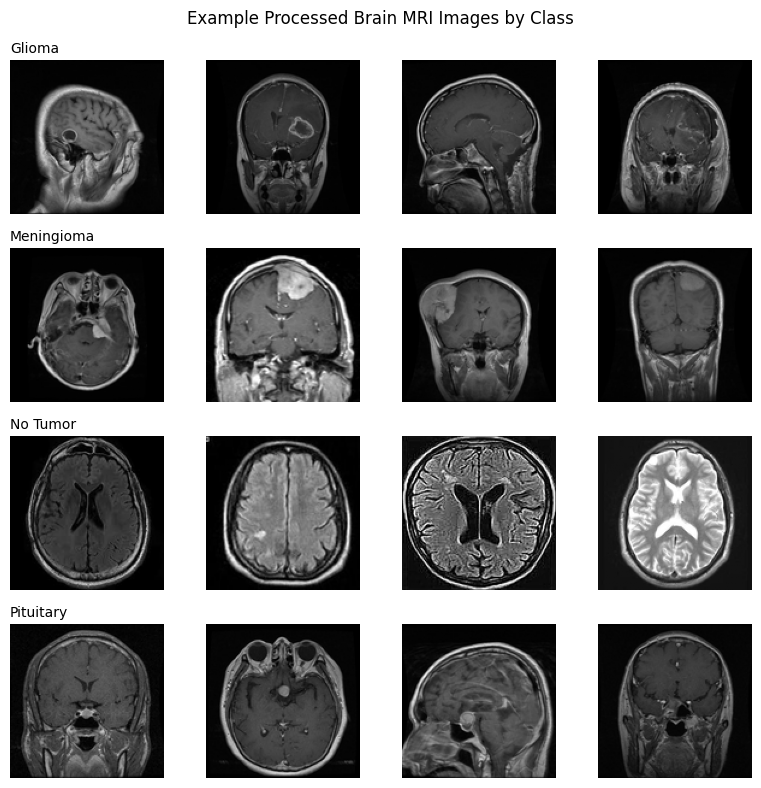

In [3]:
# visualize preprocessed images of same size
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
fig.suptitle('Example Processed Brain MRI Images by Class', fontsize=12)

# look at training/val data
for row, (cls, label_name) in enumerate(zip(classes, class_labels)):
    idxs = np.where(y_all == row)[0]
    sample_idxs = np.random.choice(idxs, 4, replace=False)
    for col, idx in enumerate(sample_idxs):
        axes[row, col].imshow(X_all[idx], cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(label_name, fontsize=10, loc='left')

plt.tight_layout()
plt.show()

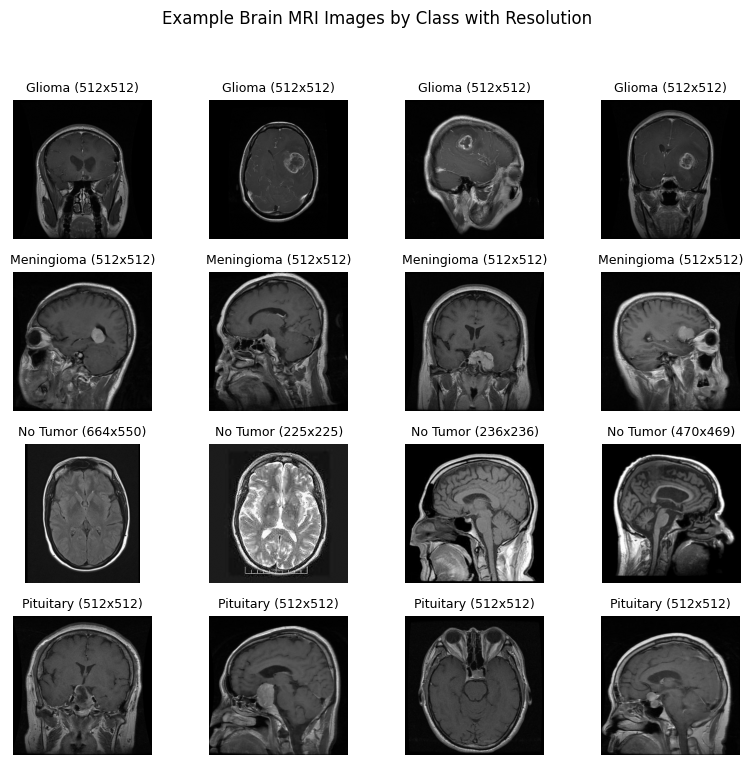

In [4]:
# visualize raw images (varying resolution)
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
fig.suptitle('Example Brain MRI Images by Class with Resolution', fontsize=12)

num_examples_per_class = 4

for row, (cls, label_name) in enumerate(zip(classes, class_labels)):
    idxs = np.where(y_all == row)[0]
    sample_idxs = np.random.choice(idxs, num_examples_per_class, replace=False)

    for col, idx in enumerate(sample_idxs):
        original_fpath = X_all_paths[idx]
        # LOOK AT ORIG IMG NOT RESIZED
        original_img = Image.open(original_fpath).convert('L')
        original_arr = np.array(original_img)

        axes[row, col].imshow(original_arr, cmap='gray', vmin=0, vmax=255)
        axes[row, col].axis('off')
        axes[row, col].set_title(f'{label_name} ({original_arr.shape[0]}x{original_arr.shape[1]})', fontsize=9)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### HOG Features

In [5]:
def extract_hog(images):
    feats = []
    # compute edge and gradient based features
    for img in images:
        # determine how fine our representation is
        hog_ex = hog(img, orientations=12, pixels_per_cell=(4, 4),
                 cells_per_block=(2, 2), block_norm='L2-Hys',
                 visualize=False, feature_vector=True)
        feats.append(hog_ex)
    return np.array(feats)

t0 = time.time()
hog_train = extract_hog(X_train_raw)
hog_val = extract_hog(X_val_raw)
hog_test= extract_hog(X_test_raw)
hog_time = time.time() - t0
print(f'HOG feature shape: {hog_train.shape} extracted in time: {hog_time:.1f}s')

HOG feature shape: (4343, 46128) extracted in time: 143.5s


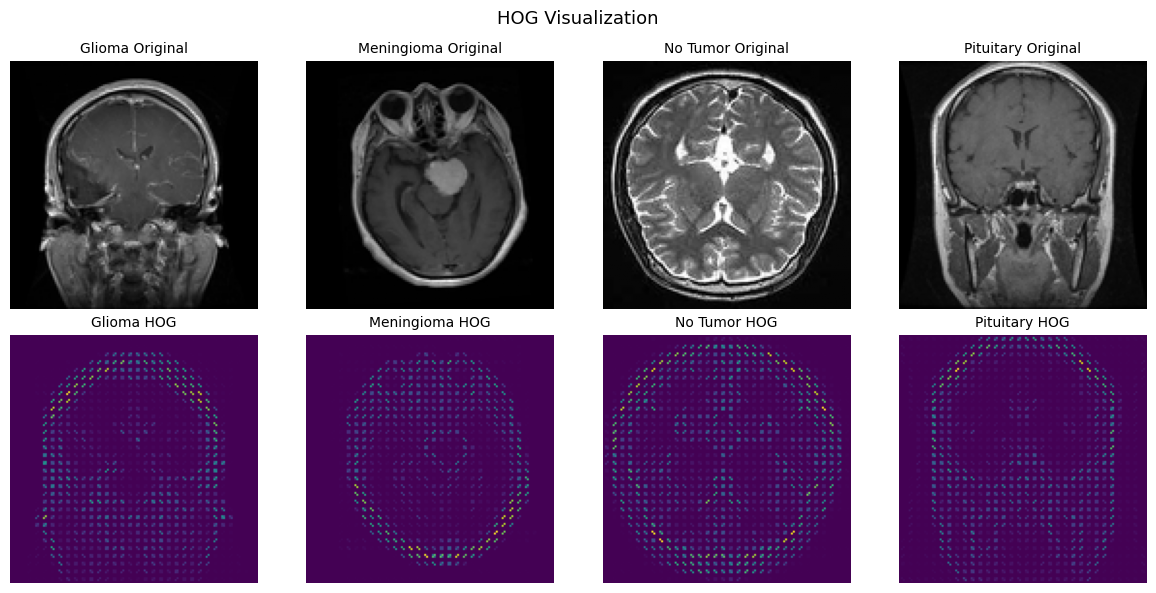

In [6]:
# visualize hog
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('HOG Visualization', fontsize=13)

for row, (cls, label_name) in enumerate(zip(classes, class_labels)):
    idx = np.where(y_all == row)[0][0]
    img = X_all[idx]
    hog_ex, hog_img = hog(img, orientations=12, pixels_per_cell=(4, 4),
                      cells_per_block=(2, 2), block_norm='L2-Hys',
                      visualize=True, feature_vector=True)
    hog_img_rescaled = exposure.rescale_intensity(hog_img, in_range=(0, 10))

    axes[0, row].imshow(img, cmap='gray')
    axes[0, row].set_title(f'{label_name} Original', fontsize=10)
    axes[0, row].axis('off')

    axes[1, row].imshow(hog_img_rescaled, cmap='viridis')
    axes[1, row].set_title(f'{label_name} HOG', fontsize=10)
    axes[1, row].axis('off')

plt.tight_layout()
plt.show()

### LBP Features


In [7]:
def extract_lbp_spatial(images, radius, n_points, n_bins, grid=(4, 4)):
    feats = []
    gx, gy = grid

    for img in images:
        h, w = img.shape

        # compute lbp version of the image by replacing each pixel with its local binary pattern value
        lbp = local_binary_pattern(img, n_points, radius, method='uniform')

        # compute h and w of cell grid via grid cell
        cell_h, cell_w = h // gy, w // gx
        hist_all = []

        for i in range(gy):
            for j in range(gx):
                # compute normalized his of subregion
                cell = lbp[i*cell_h:(i+1)*cell_h, j* cell_w:(j+1)*cell_w]
                hist, _ = np.histogram(cell.ravel(), bins=n_bins,
                                       range=(0, n_bins), density=True)
                #  store above
                hist_all.extend(hist)

        feats.append(hist_all)

    return np.array(feats)

lbp_train = extract_lbp_spatial(X_train_raw, 3, 24, 26, grid=(4, 4))
lbp_val = extract_lbp_spatial(X_val_raw, 3, 24, 26, grid=(4, 4))
lbp_test = extract_lbp_spatial(X_test_raw,  3, 24, 26, grid=(4, 4))


In [ ]:
# visualize lbp WITH histograms to see how well we've picking up texture variety
fig, axes = plt.subplots(4, 3, figsize=(13, 14))
fig.suptitle('LBP Feature Visualization', fontsize=13, fontweight='bold')

for row, (cls, label_name) in enumerate(zip(classes, class_labels)):
    idx = np.where(y_all == row)[0][0]
    img = X_all[idx]
    lbp_img = local_binary_pattern(img, 24, 3, method='uniform')
    mask = y_all == row
    # get mean histogram for the sample image
    mean_hist = lbp_train[y_train == row].mean(axis=0)

    axes[row, 0].imshow(img, cmap='gray')
    axes[row, 0].set_title(f'{label_name}\nOriginal', fontsize=9)
    axes[row, 0].axis('off')
    axes[row, 1].imshow(lbp_img, cmap='viridis')
    axes[row, 1].set_title(f'{label_name}\nLBP Visual', fontsize=9)
    axes[row, 1].axis('off')
    axes[row, 2].bar(range(len(mean_hist)), mean_hist, color='#759B9E', alpha=0.8)
    axes[row, 2].set_title(f'{label_name}\nMean LBP Histogram', fontsize=9)
    axes[row, 2].set_xlabel('LBP bin')
    axes[row, 2].set_ylabel('Density')

plt.tight_layout()
plt.show()

### ResNet18


In [9]:
# load pre-trained ResNet18 that's trained on ImageNet
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# remove final classif layer so that we can output feature vector rather than class predic
resnet.fc = torch.nn.Identity()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
resnet = resnet.to(device)
resnet.eval()

# ImageNet normalization
resnet_transform = transforms.Compose([
    #resnet trained on 224 SO need to resize to this
    transforms.Resize(224),
    transforms.CenterCrop(224),
    # convert PIL image to PyTorch tensor
    transforms.ToTensor(),
    # normalize using Imagenet mean and std
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std =[0.229, 0.224, 0.225])])

def extract_resnet(images, batch_size=64):
    all_feats = []
    n = len(images)

    # process images in batches
    for start in range(0, n, batch_size):
        batch_imgs = images[start:start+batch_size]
        tensors = []

        for img in batch_imgs:
          # convert normalized grayscale image [0,1] to uint8 [0,255] and convert to PIL and replicate to RGB
            pil = Image.fromarray((img * 255).astype(np.uint8), mode='L').convert('RGB')
            # THEN apply ResNet preprocessing
            tensors.append(resnet_transform(pil))

        batch_tensor = torch.stack(tensors).to(device)

        # disabled for efficiency ie less memory and faster
        with torch.no_grad():
            # extract features from batch_tens
            feats = resnet(batch_tensor).cpu().numpy()

        all_feats.append(feats)

    return np.vstack(all_feats)

print('Start extracting ResNet18 feature')
t0 = time.time()

print("start res train")
res_train = extract_resnet(X_train_raw)

print("start res val")
res_val   = extract_resnet(X_val_raw)

print("start res test")
res_test  = extract_resnet(X_test_raw)

res_time  = time.time() - t0

print(f'ResNet18 feature shape: {res_train.shape} (time: {res_time:.1f}s)')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 234MB/s]


Start extracting ResNet18 feature
start res train
start res val
start res test
ResNet18 feature shape: (4343, 512) (time: 12.6s)


### combined feature vector for combining features

In [10]:
# Concat HOG, LBP into combined feature vector
hog_lbp_train = np.hstack([hog_train,lbp_train])
hog_lbp_val = np.hstack([hog_val, lbp_val])
hog_lbp_test = np.hstack([hog_test, lbp_test])

# Concat HOG, LBP, ResNet18 into combined feature vector
hog_lbp_res_train = np.hstack([hog_train, lbp_train, res_train])
hog_lbp_res_val   = np.hstack([hog_val,   lbp_val,   res_val])
hog_lbp_res_test  = np.hstack([hog_test,  lbp_test,  res_test])

print(f'HOG dim {hog_train.shape[1]}d')
print(f'LBP dim {lbp_train.shape[1]}d')
print(f'ResNet18 dim {res_train.shape[1]}d')
print(f'HOG+LBP dim {hog_lbp_train.shape[1]}d')
print(f'HOG+LBP+ResNet18 dim {hog_lbp_res_train.shape[1]}d')

HOG dim 46128d
LBP dim 416d
ResNet18 dim 512d
HOG+LBP dim 46544d
HOG+LBP+ResNet18 dim 47056d


---
## PCA & t-SNE

In [11]:
# Standardize all features before pca/t-sne
def standardize(train, val, test):
    scaler = StandardScaler()
    return scaler.fit_transform(train), scaler.transform(val), scaler.transform(test), scaler

hog_tr_s, hog_v_s, hog_te_s, sc_hog = standardize(hog_train, hog_val, hog_test)
lbp_tr_s, lbp_v_s, lbp_te_s, sc_lbp = standardize(lbp_train, lbp_val, lbp_test)
hl_tr_s,  hl_v_s,  hl_te_s,  sc_hl  = standardize(hog_lbp_train, hog_lbp_val, hog_lbp_test)
res_tr_s, res_v_s, res_te_s, sc_res  = standardize(res_train, res_val, res_test)
all_tr_s, all_v_s, all_te_s, sc_all  = standardize(hog_lbp_res_train, hog_lbp_res_val, hog_lbp_res_test)

print('Standardization complete')

Standardization complete


In [ ]:
# Feature sets
feature_sets = {'HOG': hog_tr_s,
                'LBP': lbp_tr_s,
                'HOG + LBP': hl_tr_s,
                'ResNet18': res_tr_s,
                'All': all_tr_s}

fig, axes = plt.subplots(1, 5, figsize=(20, 7))

for ax, (feat, train) in zip(axes, feature_sets.items()):
    print(f'\nStart fitting PCA for {feat}...')

    pca_full = PCA(random_state=42)
    # fit training data for pca
    pca_full.fit(train)

    #determie how much total variance is captured as we add components
    cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100
    x = np.arange(1, len(cumvar) + 1)

    if np.any(cumvar >= 90):
        # find the first index where cumulative variance >= 90p
        n90 = np.argmax(cumvar >= 90) + 1
        title = f'{feat}\n({n90} PCs)'
        print(f'{feat}: 90% variance at {n90} PCs')
    else:
        n90 = None
        title = f'{feat}\n(<90%)'
        print(f'{feat}: 90% variance not reached')

    # Plot
    ax.plot(x, cumvar, 'o-', markersize=3)
    ax.axhline(90, color='red', linestyle='--')

    if n90 is not None:
        ax.axvline(n90, linestyle='--', color='green', alpha=0.8)
        ax.scatter(n90, cumvar[n90 - 1], s=40)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel('PCs')
    ax.set_ylim(0, 105)
    ax.grid(alpha=0.3)

# Only label y-axis once (cleaner look)
axes[0].set_ylabel('% Cumulative Explained Variance')

plt.suptitle('PCA Across Feature Types',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


In [13]:
print('Applying PCA to retain 90% variance and compare with original dimension')
# HOG
pca_hog_90 = PCA(n_components=0.90, svd_solver='full', random_state=42)
hog_train_pca = pca_hog_90.fit_transform(hog_tr_s)
hog_val_pca   = pca_hog_90.transform(hog_v_s)
hog_test_pca  = pca_hog_90.transform(hog_te_s)

# LBP
pca_lbp_90 = PCA(n_components=0.90, svd_solver='full', random_state=42)
lbp_train_pca = pca_lbp_90.fit_transform(lbp_tr_s)
lbp_val_pca   = pca_lbp_90.transform(lbp_v_s)
lbp_test_pca  = pca_lbp_90.transform(lbp_te_s)

# ResNet18
pca_res_90 = PCA(n_components=0.90, svd_solver='full', random_state=42)
res_train_pca = pca_res_90.fit_transform(res_tr_s)
res_val_pca   = pca_res_90.transform(res_v_s)
res_test_pca  = pca_res_90.transform(res_te_s)

# HOG + LBP
pca_hl_90 = PCA(n_components=0.90, svd_solver='full', random_state=42)
hl_train_pca = pca_hl_90.fit_transform(hl_tr_s)
hl_val_pca   = pca_hl_90.transform(hl_v_s)
hl_test_pca  = pca_hl_90.transform(hl_te_s)

# ALL
pca_all_90 = PCA(n_components=0.90, svd_solver='full', random_state=42)
all_train_pca = pca_all_90.fit_transform(all_tr_s)
all_val_pca   = pca_all_90.transform(all_v_s)
all_test_pca  = pca_all_90.transform(all_te_s)

print('PCA reduction results')

print(f'\nHOG')
print(f'Original dimension: {hog_tr_s.shape[1]}')
print(f'Reduced dimension: {hog_train_pca.shape[1]}')
print(f'Total explained variance retained: {pca_hog_90.explained_variance_ratio_.sum() * 100:.2f}%')

print(f'\nLBP')
print(f'Original dimension: {lbp_tr_s.shape[1]}')
print(f'Reduced dimension: {lbp_train_pca.shape[1]}')
print(f'Total explained variance retained: {pca_lbp_90.explained_variance_ratio_.sum() * 100:.2f}%')

print(f'\nResNet18')
print(f'Original dimension: {res_tr_s.shape[1]}')
print(f'Reduced dimension: {res_train_pca.shape[1]}')
print(f'Total explained variance retained: {pca_res_90.explained_variance_ratio_.sum() * 100:.2f}%')

print(f'\nHOG + LBP')
print(f'Original dimension: {hl_tr_s.shape[1]}')
print(f'Reduced dimension: {hl_train_pca.shape[1]}')
print(f'Total explained variance retained: {pca_hl_90.explained_variance_ratio_.sum() * 100:.2f}%')

print(f'\nHOG + LBP + ResNet18')
print(f'Original dimension: {all_tr_s.shape[1]}')
print(f'Reduced dimension: {all_train_pca.shape[1]}')
print(f'Total explained variance retained: {pca_all_90.explained_variance_ratio_.sum() * 100:.2f}%')

Applying PCA to retain 90% variance and compare with original dimension
PCA reduction results

HOG
Original dimension: 46128
Reduced dimension: 2632
Total explained variance retained: 90.01%

LBP
Original dimension: 416
Reduced dimension: 202
Total explained variance retained: 90.01%

ResNet18
Original dimension: 512
Reduced dimension: 156
Total explained variance retained: 90.07%

HOG + LBP
Original dimension: 46544
Reduced dimension: 2634
Total explained variance retained: 90.00%

HOG + LBP + ResNet18
Original dimension: 47056
Reduced dimension: 2636
Total explained variance retained: 90.01%


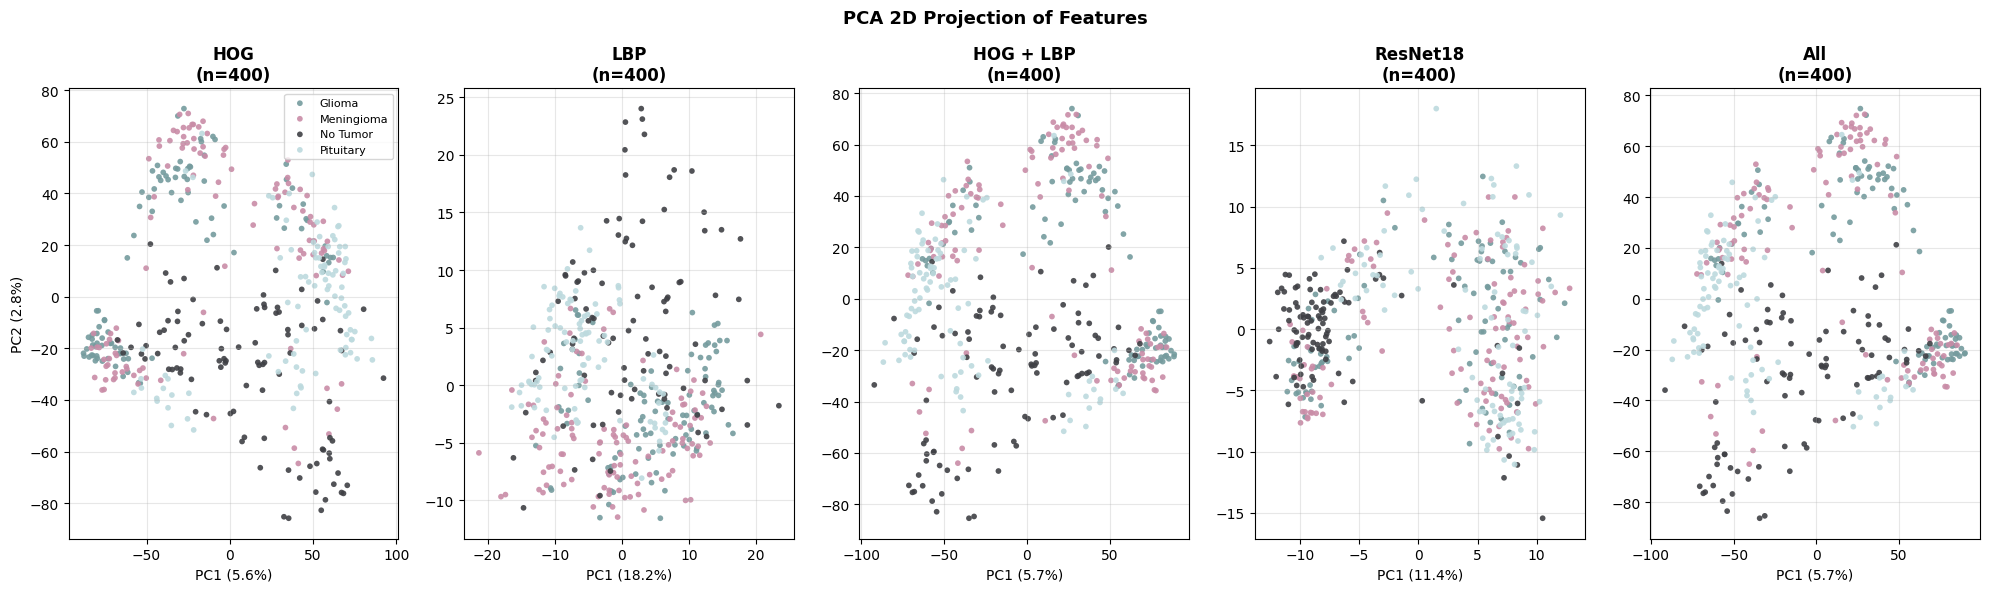

In [14]:
# visualize PCA 2D scatter for all features
fig, axes = plt.subplots(1, 5, figsize=(20, 6))
fig.suptitle('PCA 2D Projection of Features', fontsize=13, fontweight='bold')

colors = ['#759B9E', '#C98CA7', '#3F4045', '#BDDADE']

feature_sets = {'HOG': hog_tr_s,
                'LBP': lbp_tr_s,
                'HOG + LBP': hl_tr_s,
                'ResNet18': res_tr_s,
                'All': all_tr_s}

# use a shared subset for fair comparison across feature types
num = 400
idx_plot = np.random.choice(len(y_train), min(num, len(y_train)), replace=False)
labels_plot = y_train[idx_plot]

for ax, (feature_name, feats_all) in zip(axes, feature_sets.items()):
    feats_plot = feats_all[idx_plot]

    #reduce to 2D for visualization
    pca2 = PCA(n_components=2, random_state=42)
    proj = pca2.fit_transform(feats_plot)

    for i, (cls, c) in enumerate(zip(class_labels, colors)):
        mask = labels_plot == i
        ax.scatter(proj[mask, 0], proj[mask, 1],
                    c=c, label=cls, alpha=0.9, s=17,edgecolors='none')

    ax.set_title(f'{feature_name}\n(n={len(idx_plot)})', fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0] * 100:.1f}%)')
    if ax is axes[0]:
        ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1] * 100:.1f}%)')
    else:
        ax.set_ylabel('')
    ax.grid(alpha=0.3)

# Only put legend  once to keep it cleaner
axes[0].legend(fontsize=8)

plt.tight_layout()
plt.show()

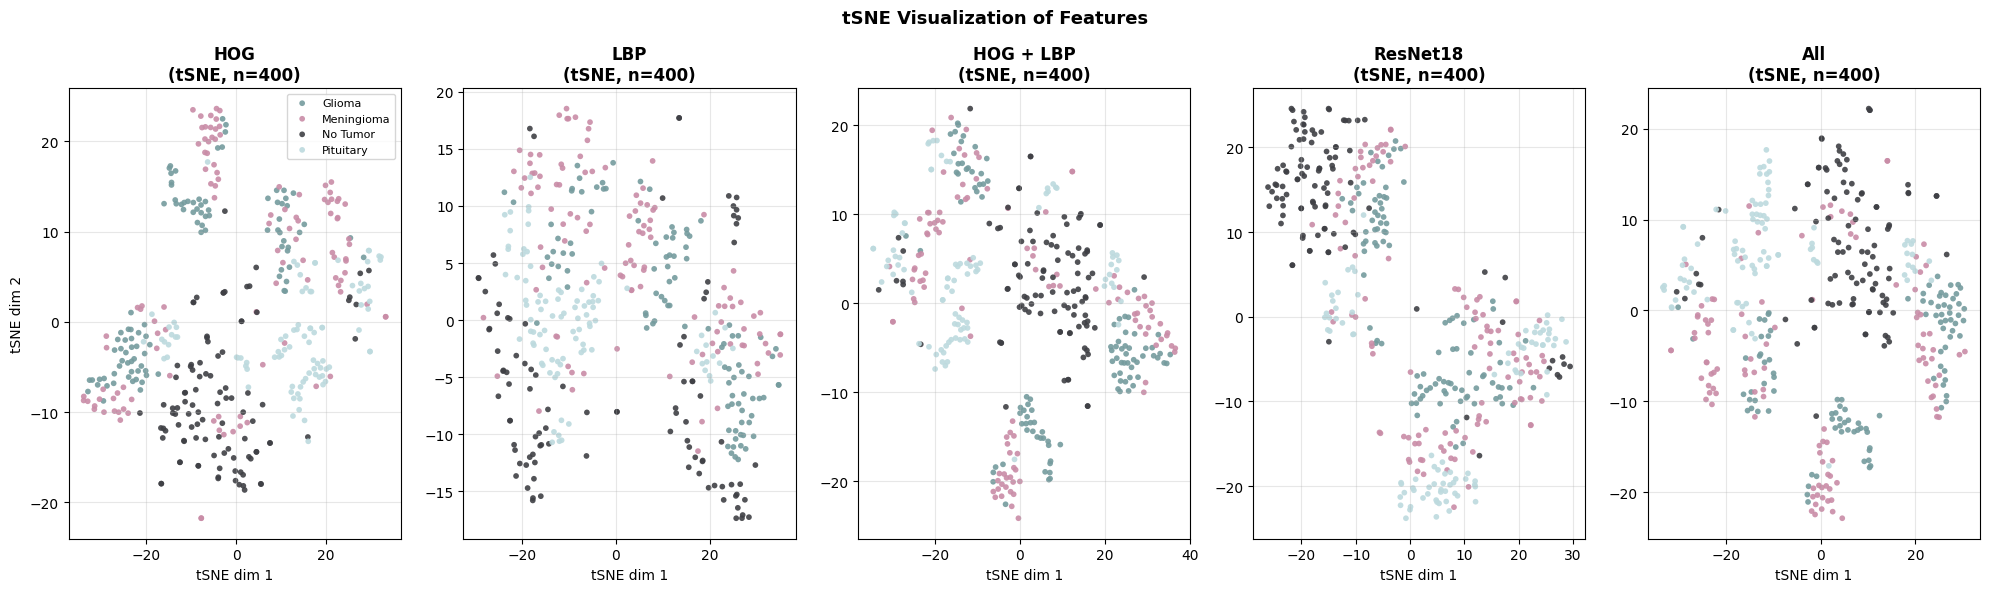

In [15]:
# tSNE visualization
colors = ['#759B9E', '#C98CA7', '#3F4045', '#BDDADE']

feature_sets = {'HOG': hog_tr_s,
                'LBP': lbp_tr_s,
                'HOG + LBP': hl_tr_s,
                'ResNet18': res_tr_s,
                'All': all_tr_s}

# use a shared subset for fair comparison across feature types like above
N_PLOT = 400
idx_plot = np.random.choice(len(y_train), min(N_PLOT, len(y_train)), replace=False)
labels_sub = y_train[idx_plot]

fig, axes = plt.subplots(1, 5, figsize=(20, 6))
fig.suptitle('tSNE Visualization of Features', fontsize=13, fontweight='bold')

for ax, (feature_name, feats_all) in zip(axes, feature_sets.items()):
    # get subset of features
    sub = feats_all[idx_plot]

    # reduce with PCA before tSNE for efficiency
    n_comp_pre = min(50, sub.shape[0], sub.shape[1])
    pca_pre = PCA(n_components=n_comp_pre, random_state=42)
    sub_pca = pca_pre.fit_transform(sub)

    # Run and fit tSNE
    tsne = TSNE(n_components=2,
                perplexity=30,
                max_iter=1000,
                random_state=42)
    proj = tsne.fit_transform(sub_pca)

    # plot each one
    for i, (cls, c) in enumerate(zip(class_labels, colors)):
        mask = labels_sub == i
        ax.scatter(proj[mask, 0],proj[mask, 1],
                   c=c, label=cls,alpha=0.9, s=17, edgecolors='none')

    ax.set_title(f'{feature_name}\n(tSNE, n={len(idx_plot)})', fontweight='bold')
    ax.set_xlabel('tSNE dim 1')
    if ax is axes[0]:
        ax.set_ylabel('tSNE dim 2')
    else:
        ax.set_ylabel('')
    ax.grid(alpha=0.3)

axes[0].legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Classification

1. Support Vector Machine
2. Logistic Regression

In [16]:
# reduce pca function for feature classification later
def reduce_pca(train, val, test, n_components):
    n_comp = min(n_components, train.shape[1], train.shape[0] - 1)
    pca = PCA(n_components=n_comp, random_state=42)

    # fit on train ONLY
    pca_tr = pca.fit_transform(train)

    # apply same transform on val and test to prevent leakage (don't refit)
    pca_val  = pca.transform(val)
    pca_test = pca.transform(test)
    return pca_tr, pca_val, pca_test, pca

#Trying several PCA sizes to see which is best for classific results
pca_dims = [50, 100, 200, 300, 500, 1000]
pca_dims_lbp = [50, 100, 200]
pca_dims_res = [50, 100, 150]

hog_pca_versions = {}
lbp_pca_versions = {}
hl_pca_versions  = {}
res_pca_versions = {}
all_pca_versions = {}

print('Reducing HOG feats')
for d in pca_dims:
    hog_tr_r, hog_v_r, hog_te_r, pca_model = reduce_pca(hog_tr_s, hog_v_s, hog_te_s, d)
    explained = pca_model.explained_variance_ratio_.sum() * 100
    hog_pca_versions[d] = (hog_tr_r, hog_v_r, hog_te_r, pca_model)
    print(f'HOG PCA={d}, explained variance = {explained:.2f}%')

print('\nReducing LBP feats')
for d in pca_dims_lbp:
    lbp_tr_r, lbp_v_r, lbp_te_r, pca_model = reduce_pca(lbp_tr_s, lbp_v_s, lbp_te_s, d)
    explained = pca_model.explained_variance_ratio_.sum() * 100
    lbp_pca_versions[d] = (lbp_tr_r, lbp_v_r, lbp_te_r, pca_model)
    print(f'LBP PCA={d}, explained variance = {explained:.2f}%')

print('\nReducing ResNet18 feats')
for d in pca_dims_res:
    res_tr_r, res_v_r, res_te_r, pca_model = reduce_pca(res_tr_s, res_v_s, res_te_s, d)
    explained = pca_model.explained_variance_ratio_.sum() * 100
    res_pca_versions[d] = (res_tr_r, res_v_r, res_te_r, pca_model)
    print(f'ResNet18 PCA={d}, explained variance = {explained:.2f}%')

print('\nReducing HOG+LBP feats')
for d in pca_dims:
    hl_tr_r, hl_v_r, hl_te_r, pca_model = reduce_pca(hl_tr_s, hl_v_s, hl_te_s, d)
    explained = pca_model.explained_variance_ratio_.sum() * 100
    hl_pca_versions[d] = (hl_tr_r, hl_v_r, hl_te_r, pca_model)
    print(f'HOG+LBP PCA={d}, explained variance = {explained:.2f}%')

print('\nReducing HOG+LBP+ResNet18 feats')
for d in pca_dims:
    all_tr_r, all_v_r, all_te_r, pca_model = reduce_pca(all_tr_s, all_v_s, all_te_s, d)
    explained = pca_model.explained_variance_ratio_.sum() * 100
    all_pca_versions[d] = (all_tr_r, all_v_r, all_te_r, pca_model)
    print(f'HOG+LBP+ResNet18 PCA={d}, explained variance = {explained:.2f}%')


# Put all feature configurations into one dict
# will be useful for hyperparam search in a bit
feature_configs = {}

for d, (hog_tr_r, hog_v_r, hog_te_r, pca_model) in hog_pca_versions.items():
    feature_configs[f'HOG_PCA_{d}'] = (hog_tr_r, hog_v_r, hog_te_r, pca_model)

for d, (lbp_tr_r, lbp_v_r, lbp_te_r, pca_model) in lbp_pca_versions.items():
    feature_configs[f'LBP_PCA_{d}'] = (lbp_tr_r, lbp_v_r, lbp_te_r, pca_model)

for d, (hl_tr_r, hl_v_r, hl_te_r, pca_model) in hl_pca_versions.items():
    feature_configs[f'HOG_LBP_PCA_{d}'] = (hl_tr_r, hl_v_r, hl_te_r, pca_model)

for d, (res_tr_r, res_v_r, res_te_r, pca_model) in res_pca_versions.items():
    feature_configs[f'ResNet18_PCA_{d}'] = (res_tr_r, res_v_r, res_te_r, pca_model)

for d, (all_tr_r, all_v_r, all_te_r, pca_model) in all_pca_versions.items():
    feature_configs[f'AllFeat_PCA_{d}'] = (all_tr_r, all_v_r, all_te_r, pca_model)


##### START SVM HYPTERPARAMETER SEARCHING ######
# looking over regularization and region of influence
svm_param_grid = {'C': [1., 10.0, 15.0, 50.],
                  'gamma': ['scale', 0.01]}

print('\n.... SVM Hyperparameter Search .....')
svm_best = {}
overall_best_acc = 0
overall_best_feat = None
overall_best_params = None
overall_best_model = None

for feat_name, (tr_r, v_r, te_r, *_) in feature_configs.items():
    print(f'\nsearching SVM params for {feat_name}...')
    best_acc = 0
    best_params = None
    best_model = None

    # grid search parameters defined above
    for params in ParameterGrid(svm_param_grid):
        clf = SVC(kernel='rbf',
                  C=params['C'],
                  gamma=params['gamma'],
                  random_state=42,
                  max_iter=3000)

        clf.fit(tr_r, y_train)
        # get predictions
        train_pred = clf.predict(tr_r)
        val_pred = clf.predict(v_r)

        # get accuracies
        train_acc = accuracy_score(y_train, train_pred)
        val_acc = accuracy_score(y_val, val_pred)

        # get train-val gap for overfitting indicator
        gap = train_acc - val_acc

        print(f'{params} have train={train_acc:.4f}, val={val_acc:.4f}, gap={gap:.4f}')

        # update which model is best
        if val_acc > best_acc:
            best_acc = val_acc
            best_params = params
            best_model = clf

    svm_best[feat_name] = (best_params, best_acc, best_model)
    print(f'Best for {feat_name}: params= {best_params}, val_acc ={best_acc:.4f}')

    # find which one was best of SVM run
    if best_acc > overall_best_acc:
        overall_best_acc = best_acc
        overall_best_feat = feat_name
        overall_best_params = best_params
        overall_best_model = best_model

print('\n ...... Overall Best SVM Configuration .....')
print(f'Feature set: {overall_best_feat}')
print(f'Best params: {overall_best_params}')
print(f'Validation accuracy: {overall_best_acc:.4f}')

Reducing HOG feats
HOG PCA=50, explained variance = 24.50%
HOG PCA=100, explained variance = 29.40%
HOG PCA=200, explained variance = 35.96%
HOG PCA=300, explained variance = 40.92%
HOG PCA=500, explained variance = 48.42%
HOG PCA=1000, explained variance = 62.97%

Reducing LBP feats
LBP PCA=50, explained variance = 68.72%
LBP PCA=100, explained variance = 78.64%
LBP PCA=200, explained variance = 89.84%

Reducing ResNet18 feats
ResNet18 PCA=50, explained variance = 70.30%
ResNet18 PCA=100, explained variance = 82.94%
ResNet18 PCA=150, explained variance = 89.40%

Reducing HOG+LBP feats
HOG+LBP PCA=50, explained variance = 24.64%
HOG+LBP PCA=100, explained variance = 29.55%
HOG+LBP PCA=200, explained variance = 36.09%
HOG+LBP PCA=300, explained variance = 41.04%
HOG+LBP PCA=500, explained variance = 48.51%
HOG+LBP PCA=1000, explained variance = 63.01%

Reducing HOG+LBP+ResNet18 feats
HOG+LBP+ResNet18 PCA=50, explained variance = 24.75%
HOG+LBP+ResNet18 PCA=100, explained variance = 29.6

In [17]:
###### Logistic Regression hyperparameter search ########
# testing for regularization, chose lbfgs optimizer because we have DENSE features from PCA
# max iter set to 1000 because this is running rly slowly
lr_param_grid = {'C': [0.0025, 0.005, 0.01, 0.1],
                 'solver': ['lbfgs'],
                 'max_iter': [1000]}

print('\n... Logistic Regression hyperparameter search ....')
lr_best = {}
overall_best_acc = 0
overall_best_feat = None
overall_best_params = None
overall_best_model = None

for feat_name, (tr_r, v_r, te_r, *_) in feature_configs.items():
    print(f'\nsearching Logistic Reg params for {feat_name}...')
    best_acc = 0
    best_params = None
    best_model = None

    # grid search parameters defined above
    for params in ParameterGrid(lr_param_grid):
        clf = LogisticRegression(multi_class='multinomial',
                                C=params['C'],
                                solver=params['solver'],
                                max_iter=params['max_iter'],
                                random_state=42)

        clf.fit(tr_r, y_train)

        # get predictions
        train_pred = clf.predict(tr_r)
        val_pred = clf.predict(v_r)

        # get accuracies
        train_acc = accuracy_score(y_train, train_pred)
        val_acc = accuracy_score(y_val, val_pred)

        # get train-val gap for overfitting indicator
        gap = train_acc - val_acc

        print(f'{params} have train={train_acc:.4f}, val={val_acc:.4f}, gap={gap:.4f}')

        # update which model is best
        if val_acc > best_acc:
            best_acc = val_acc
            best_params = params
            best_model = clf

    lr_best[feat_name] = (best_params, best_acc, best_model)
    print(f'Best for {feat_name}: params={best_params}, val_acc={best_acc:.4f}')

    # find which one was best of LogReg run
    if best_acc > overall_best_acc:
        overall_best_acc = best_acc
        overall_best_feat = feat_name
        overall_best_params = best_params
        overall_best_model = best_model

print('\n..... Overall Best Logistic Regression Configuration ....')
print(f'Feature set: {overall_best_feat}')
print(f'Best params: {overall_best_params}')
print(f'Validation accuracy: {overall_best_acc:.4f}')


... Logistic Regression hyperparameter search ....

searching Logistic Reg params for HOG_PCA_50...
{'C': 0.0025, 'max_iter': 1000, 'solver': 'lbfgs'} have train=0.8856, val=0.8803, gap=0.0053
{'C': 0.005, 'max_iter': 1000, 'solver': 'lbfgs'} have train=0.8869, val=0.8766, gap=0.0103
{'C': 0.01, 'max_iter': 1000, 'solver': 'lbfgs'} have train=0.8872, val=0.8738, gap=0.0133
{'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'} have train=0.8876, val=0.8748, gap=0.0129
Best for HOG_PCA_50: params={'C': 0.0025, 'max_iter': 1000, 'solver': 'lbfgs'}, val_acc=0.8803

searching Logistic Reg params for HOG_PCA_100...
{'C': 0.0025, 'max_iter': 1000, 'solver': 'lbfgs'} have train=0.9107, val=0.8849, gap=0.0258
{'C': 0.005, 'max_iter': 1000, 'solver': 'lbfgs'} have train=0.9111, val=0.8904, gap=0.0207
{'C': 0.01, 'max_iter': 1000, 'solver': 'lbfgs'} have train=0.9116, val=0.8895, gap=0.0221
{'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'} have train=0.9114, val=0.8886, gap=0.0228
Best for HOG_PCA_100: 

# Results

In [26]:
# Evaluating ALL feature, classifier combinations on TEST set
print('\n... TEST SET RESULTS ....')
results = {}

# loop over all to find the test accuracy
for feat_name, (tr_r, v_r, te_r, *_) in feature_configs.items():
    for clf_name, best_dict in [('SVM', svm_best), ('LogReg', lr_best)]:
        best_params, val_acc, best_model = best_dict[feat_name]

        y_pred = best_model.predict(te_r)
        test_acc = accuracy_score(y_test, y_pred)

        results[(feat_name, clf_name)] = {'val_acc': val_acc, 'test_acc': test_acc,
                                          'y_pred': y_pred,'model': best_model,
                                          'params': best_params,'tr': tr_r,'v': v_r,
                                          'te': te_r}

print('\n... Best model in each feature-family/classifier group (selected by validation accuracy) ...')

# select best model within each feature family & classifier pair
feature_families = ['HOG', 'LBP', 'HOG_LBP', 'ResNet18', 'AllFeat']
classifier_names = ['SVM', 'LogReg']

best_by_group = {}

for family in feature_families:
    for clf_name in classifier_names:
        matching = [((feat_name, this_clf), info) for (feat_name, this_clf), info in results.items() if this_clf == clf_name and feat_name.startswith(family + '_PCA_')]

        # define best in group USING VALIDATION ACCURACY
        best_item = max(matching, key=lambda x: x[1]['val_acc'])
        best_by_group[(family, clf_name)] = best_item

        (feat_name, _), info = best_item
        print(f'{family} + {clf_name}: {feat_name} | '
              f'val_acc={info["val_acc"]:.3f} | test_acc={info["test_acc"]:.3f}')


... TEST SET RESULTS ....

... Best model in each feature-family/classifier group (selected by validation accuracy) ...
HOG + SVM: HOG_PCA_100 | val_acc=0.960 | test_acc=0.918
HOG + LogReg: HOG_PCA_1000 | val_acc=0.921 | test_acc=0.852
LBP + SVM: LBP_PCA_50 | val_acc=0.937 | test_acc=0.883
LBP + LogReg: LBP_PCA_100 | val_acc=0.843 | test_acc=0.754
HOG_LBP + SVM: HOG_LBP_PCA_100 | val_acc=0.959 | test_acc=0.920
HOG_LBP + LogReg: HOG_LBP_PCA_1000 | val_acc=0.924 | test_acc=0.857
ResNet18 + SVM: ResNet18_PCA_150 | val_acc=0.957 | test_acc=0.927
ResNet18 + LogReg: ResNet18_PCA_150 | val_acc=0.899 | test_acc=0.843
AllFeat + SVM: AllFeat_PCA_100 | val_acc=0.961 | test_acc=0.920
AllFeat + LogReg: AllFeat_PCA_1000 | val_acc=0.932 | test_acc=0.862


In [30]:
# FOR EFFICIENCY CALCULATION:
# Determine time it takes to extract features on 100 image subset
n_toTime = 100
subset = X_train_raw[:n_toTime]

# Get HOG time
t0 = time.time()
extract_hog(subset)
t_hog_per_img = (time.time() - t0) / n_toTime * 1000

# Get LBP time
t0 = time.time()
extract_lbp_spatial(subset, radius=3, n_points=24, n_bins=26)
t_lbp_per_img = (time.time() - t0) / n_toTime * 1000

# Get ResNet18 time
t0 = time.time()
extract_resnet(subset, batch_size=64)
t_res_per_img = (time.time() - t0) / n_toTime * 1000

# Get Combined feature extraction times
# simple addition for the time to extract
t_hog_lbp_per_img = t_hog_per_img + t_lbp_per_img
t_allfeat_per_img = t_hog_per_img + t_lbp_per_img + t_res_per_img

print('Feature extraction time (ms/image):')
print(f'HOG: {t_hog_per_img:.2f} ms')
print(f'LBP: {t_lbp_per_img:.2f} ms')
print(f'ResNet18: {t_res_per_img:.2f} ms')
print(f'HOG+LBP: {t_hog_lbp_per_img:.2f} ms')
print(f'HOG+LBP+ResNet18: {t_allfeat_per_img:.2f} ms')

# assign feature extraction time
feat_extract_times = {'HOG': t_hog_per_img,
                      'LBP': t_lbp_per_img,
                      'ResNet18': t_res_per_img,
                      'HOG_LBP': t_hog_lbp_per_img,
                      'AllFeat': t_allfeat_per_img}


# NOW time how long it takes for the classifier to make a prediction on the feature config
# using test set
clf_inference_times = {}

for feat_name, (tr_r, v_r, te_r, *_) in feature_configs.items():
    for clf_name, best_dict in [('SVM', svm_best), ('LogReg', lr_best)]:
        model = best_dict[feat_name][2]

        # time the prediction
        t0 = time.time()
        _ = model.predict(te_r)
        t_inf = (time.time() - t0) / len(te_r) * 1000  # ms per image

        clf_inference_times[(feat_name, clf_name)] = t_inf


# Determine total inference cost for BEST model in each family/classifier pairing
# total time = extract time + predict time
feature_families = ['HOG', 'LBP', 'ResNet18', 'HOG_LBP', 'AllFeat']
clf_names = ['SVM', 'LogReg']

total_times = {}

print('\ntotal inference time (ms/image):')
for family in feature_families:
    for clf_name in clf_names:
        (best_feat_name, _), best_info = best_by_group[(family, clf_name)]

        total_time = feat_extract_times[family] + clf_inference_times[(best_feat_name, clf_name)]
        total_times[(family, clf_name)] = total_time

        print(f'\n{family} + {clf_name}:',f'{total_time:.3f} ms',
              f'with best config={best_feat_name} and test_acc={best_info["test_acc"]:.3f}')

Feature extraction time (ms/image):
HOG: 20.37 ms
LBP: 10.45 ms
ResNet18: 1.87 ms
HOG+LBP: 30.82 ms
HOG+LBP+ResNet18: 32.69 ms

total inference time (ms/image):

HOG + SVM: 20.561 ms with best config=HOG_PCA_100 and test_acc=0.918

HOG + LogReg: 20.376 ms with best config=HOG_PCA_1000 and test_acc=0.852

LBP + SVM: 10.709 ms with best config=LBP_PCA_50 and test_acc=0.883

LBP + LogReg: 10.447 ms with best config=LBP_PCA_100 and test_acc=0.754

ResNet18 + SVM: 2.297 ms with best config=ResNet18_PCA_150 and test_acc=0.927

ResNet18 + LogReg: 1.867 ms with best config=ResNet18_PCA_150 and test_acc=0.843

HOG_LBP + SVM: 31.004 ms with best config=HOG_LBP_PCA_100 and test_acc=0.920

HOG_LBP + LogReg: 30.822 ms with best config=HOG_LBP_PCA_1000 and test_acc=0.857

AllFeat + SVM: 32.865 ms with best config=AllFeat_PCA_100 and test_acc=0.920

AllFeat + LogReg: 32.688 ms with best config=AllFeat_PCA_1000 and test_acc=0.862


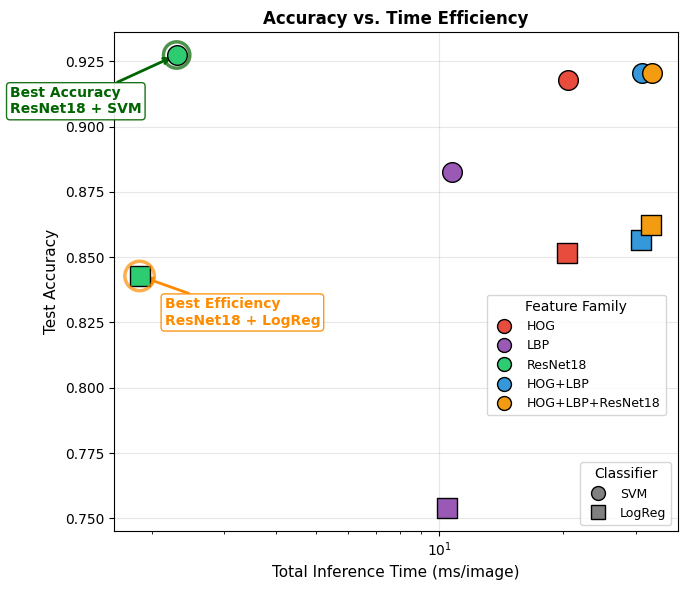


Best accuracy model: ResNet18 + SVM with test_acc=0.9274
Best efficiency model: ResNet18 + LogReg with time=1.867 ms and test_acc=0.8428


In [31]:
# Accuracy vs. efficiency scatter plot for best model in each family
fig, ax = plt.subplots(figsize=(7, 6))

# make markers different for clarity
markers = {'SVM': 'o', 'LogReg': 's'}
feat_colors = {'HOG': '#e74c3c',
               'LBP': '#9b59b6',
               'ResNet18': '#2ecc71',
               'HOG_LBP': '#3498db',
               'AllFeat': '#f39c12'}

family_display_names = {'HOG': 'HOG',
                        'LBP': 'LBP',
                        'ResNet18': 'ResNet18',
                        'HOG_LBP': 'HOG+LBP',
                        'AllFeat': 'HOG+LBP+ResNet18'}

feature_families = ['HOG', 'LBP', 'ResNet18', 'HOG_LBP', 'AllFeat']
clf_names = ['SVM', 'LogReg']

# plot only the best model from each family/classifier pair
for family in feature_families:
    for clf_name in clf_names:
        # only need result
        (_, _), res = best_by_group[(family, clf_name)]

        # get total time x-axis
        x_val = total_times[(family, clf_name)]
        # get test accuracy from res y-axis
        y_val = res['test_acc']

        ax.scatter(x_val, y_val,c=feat_colors[family],
                   marker=markers[clf_name],s=200, edgecolors='black',
                   linewidth=1., zorder=5)

# Set first legend = shape of marker for different classes
shape_legend = [Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markeredgecolor='black', markersize=10, label='SVM'),
                Line2D([0], [0], marker='s', color='w', markerfacecolor='gray',markeredgecolor='black', markersize=10, label='LogReg')]

# Set second legend = color of marker for different family of features
color_legend = [Line2D([0], [0], marker='o', color='w', markerfacecolor=feat_colors['HOG'],markeredgecolor='black', markersize=10, label='HOG'),
                Line2D([0], [0], marker='o', color='w', markerfacecolor=feat_colors['LBP'], markeredgecolor='black', markersize=10, label='LBP'),
                Line2D([0], [0], marker='o', color='w', markerfacecolor=feat_colors['ResNet18'], markeredgecolor='black', markersize=10, label='ResNet18'),
                Line2D([0], [0], marker='o', color='w', markerfacecolor=feat_colors['HOG_LBP'], markeredgecolor='black', markersize=10, label='HOG+LBP'),
                Line2D([0], [0], marker='o', color='w', markerfacecolor=feat_colors['AllFeat'], markeredgecolor='black', markersize=10, label='HOG+LBP+ResNet18')]

legend1 = ax.legend(handles=shape_legend, title='Classifier', fontsize=9,
                    title_fontsize=10, loc='lower right')
ax.add_artist(legend1)

legend2 = ax.legend(handles=color_legend, title='Feature Family', fontsize=9,
                    title_fontsize=10, loc='lower center', bbox_to_anchor=(0.82, 0.22))

ax.set_xlabel('Total Inference Time (ms/image)', fontsize=11)
ax.set_ylabel('Test Accuracy', fontsize=11)
ax.set_title('Accuracy vs. Time Efficiency', fontweight='bold', fontsize=12)
ax.set_xscale('log')
ax.grid(alpha=0.3)

# ID best accuracy model and best efficiency model in plot
valid_keys = [k for k in total_times.keys() if k in best_by_group]

best_acc_key = max(valid_keys, key=lambda k: best_by_group[k][1]['test_acc'])
best_eff_key = min(valid_keys, key=lambda k: total_times[k])

best_acc_time = total_times[best_acc_key]
best_acc_val = best_by_group[best_acc_key][1]['test_acc']

best_eff_time = total_times[best_eff_key]
best_eff_acc = best_by_group[best_eff_key][1]['test_acc']

best_acc_family, best_acc_clf = best_acc_key
best_eff_family, best_eff_clf = best_eff_key

# Emphasize the best-accuracy point
ax.scatter(best_acc_time, best_acc_val,
           s=360, facecolors='none', edgecolors='darkgreen',
           linewidths=2.5, alpha=0.7, zorder=6)

# Emphasize the best-efficiency point
ax.scatter(best_eff_time, best_eff_acc, s=450,
           facecolors='none', edgecolors='darkorange', linewidths=2.5,
           alpha=0.7, zorder=6)

# annotate best accuracy
ax.annotate(f'Best Accuracy\n{family_display_names[best_acc_family]} + {best_acc_clf}',
            xy=(best_acc_time, best_acc_val), xytext=(-120, -42), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='darkgreen', lw=2, shrinkA=0, shrinkB=4),
            color='darkgreen', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.9, ec='darkgreen'))

# annotate best efficiency
ax.annotate(f'Best Efficiency\n{family_display_names[best_eff_family]} + {best_eff_clf}',
            xy=(best_eff_time, best_eff_acc), xytext=(18, -35), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='darkorange', lw=2, shrinkA=0, shrinkB=4 ),
            color='darkorange', fontsize=10, fontweight='bold', bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.9, ec='darkorange'))

plt.tight_layout()
plt.show()

print(f'\nBest accuracy model: {family_display_names[best_acc_family]} + {best_acc_clf} with test_acc={best_acc_val:.4f}')
print(f'Best efficiency model: {family_display_names[best_eff_family]} + {best_eff_clf} with time={best_eff_time:.3f} ms and test_acc={best_eff_acc:.4f}')

In [32]:
# Run classification reports on best accuracy and best efficiency models
print('.... CLASSIFICATION REPORTS on Test Set .... \n')

selected_keys = [('Best Accuracy Model', best_acc_key), ('Best Efficiency Model', best_eff_key)]

for label, key in selected_keys:
    family, clf_name = key
    (best_feat_name, _), res = best_by_group[key]

    print(f'{label}: {clf_name} + {family}')
    print(f'Best config: {best_feat_name}')
    print(f'Validation accuracy: {res["val_acc"]:.4f}')
    print(f'Test accuracy: {res["test_acc"]:.4f}\n')
    print(classification_report(y_test, res['y_pred'], target_names=class_labels, digits=3))

.... CLASSIFICATION REPORTS on Test Set .... 

Best Accuracy Model: SVM + ResNet18
Best config: ResNet18_PCA_150
Validation accuracy: 0.9567
Test accuracy: 0.9274

              precision    recall  f1-score   support

      Glioma      0.964     0.772     0.858       386
  Meningioma      0.845     0.945     0.892       398
    No Tumor      0.932     0.998     0.964       400
   Pituitary      0.985     0.990     0.988       400

    accuracy                          0.927      1584
   macro avg      0.932     0.926     0.925      1584
weighted avg      0.931     0.927     0.926      1584

Best Efficiency Model: LogReg + ResNet18
Best config: ResNet18_PCA_150
Validation accuracy: 0.8987
Test accuracy: 0.8428

              precision    recall  f1-score   support

      Glioma      0.913     0.681     0.780       386
  Meningioma      0.720     0.781     0.749       398
    No Tumor      0.861     0.988     0.920       400
   Pituitary      0.904     0.915     0.909       400

    acc


... Best Accuracy: ResNet18 + SVM ...
Configuration: ResNet18_PCA_150
Val accuracy: 0.9567
Test accuracy: 0.9274


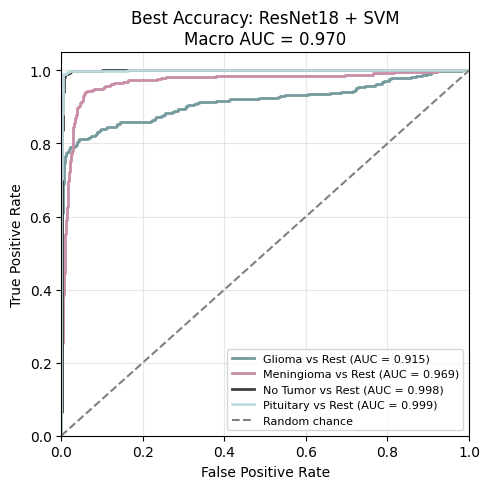

Per-class AUC:
Glioma: 0.9148
Meningioma: 0.9690
No Tumor: 0.9981
Pituitary: 0.9987
Macro AUC: 0.9702

... Best Efficiency: ResNet18 + LogReg ...
Configuration: ResNet18_PCA_150
Val accuracy: 0.8987
Test accuracy: 0.8428


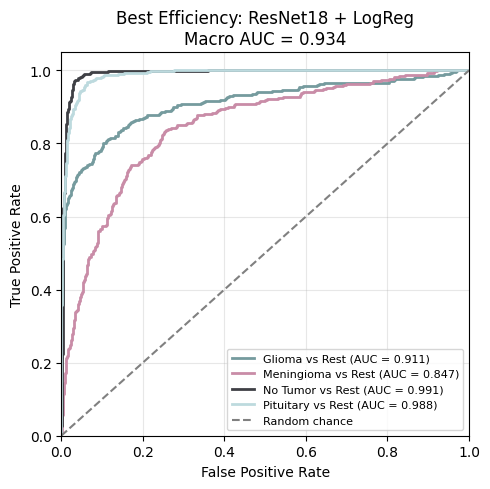

Per-class AUC:
Glioma: 0.9112
Meningioma: 0.8472
No Tumor: 0.9910
Pituitary: 0.9877
Macro AUC: 0.9343


In [33]:
def plot_ovr_roc(model, X_test, y_test, class_labels, title='One-vs-Rest ROC Curves'):
    n_classes = len(class_labels)

    # convert y_test into one-vs-rest binary indicator matrix
    y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

    # Get model scores for ROC computation
    if hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    elif hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)

    # Compute ROC curve and AUC for each class
    fpr = {}
    tpr = {}
    roc_auc = {}

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # get macro-average AUC
    macro_auc = roc_auc_score(y_test_bin, y_score, multi_class='ovr', average='macro')

    colors = ['#759B9E', '#C98CA7', '#3F4045', '#BDDADE']
    plt.figure(figsize=(5, 5))

    for i, color in enumerate(colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'{class_labels[i]} vs Rest (AUC = {roc_auc[i]:.3f})')

    # plot random choice line on diag
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random chance')
    plt.xlim([0, 1])
    plt.ylim([0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{title}\nMacro AUC = {macro_auc:.3f}')
    plt.legend(loc='lower right', fontsize=8)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print('Per-class AUC:')
    for i, cls in enumerate(class_labels):
        print(f'{cls}: {roc_auc[i]:.4f}')
    print(f'Macro AUC: {macro_auc:.4f}')

    return fpr, tpr, roc_auc, macro_auc


# add helper to clean up mismatched names
def family_display_name(family):
    if family == 'HOG_LBP':
        return 'HOG+LBP'
    elif family == 'AllFeat':
        return 'HOG+LBP+ResNet18'
    else:
        return family

selected_models = [('Best Accuracy', best_acc_key),('Best Efficiency', best_eff_key)]

for label, key in selected_models:
    family, clf_name = key
    (best_feat_name, _), best_info = best_by_group[key]

    model = best_info['model']
    X_test_model = best_info['te']

    print(f'\n... {label}: {family_display_name(family)} + {clf_name} ...')
    print(f'Configuration: {best_feat_name}')
    print(f'Val accuracy: {best_info["val_acc"]:.4f}')
    print(f'Test accuracy: {best_info["test_acc"]:.4f}')

    fpr, tpr, roc_auc, macro_auc = plot_ovr_roc(model=model,
                                                X_test=X_test_model,
                                                y_test=y_test,
                                                class_labels=class_labels,
                                                title=f'{label}: {family_display_name(family)} + {clf_name}')

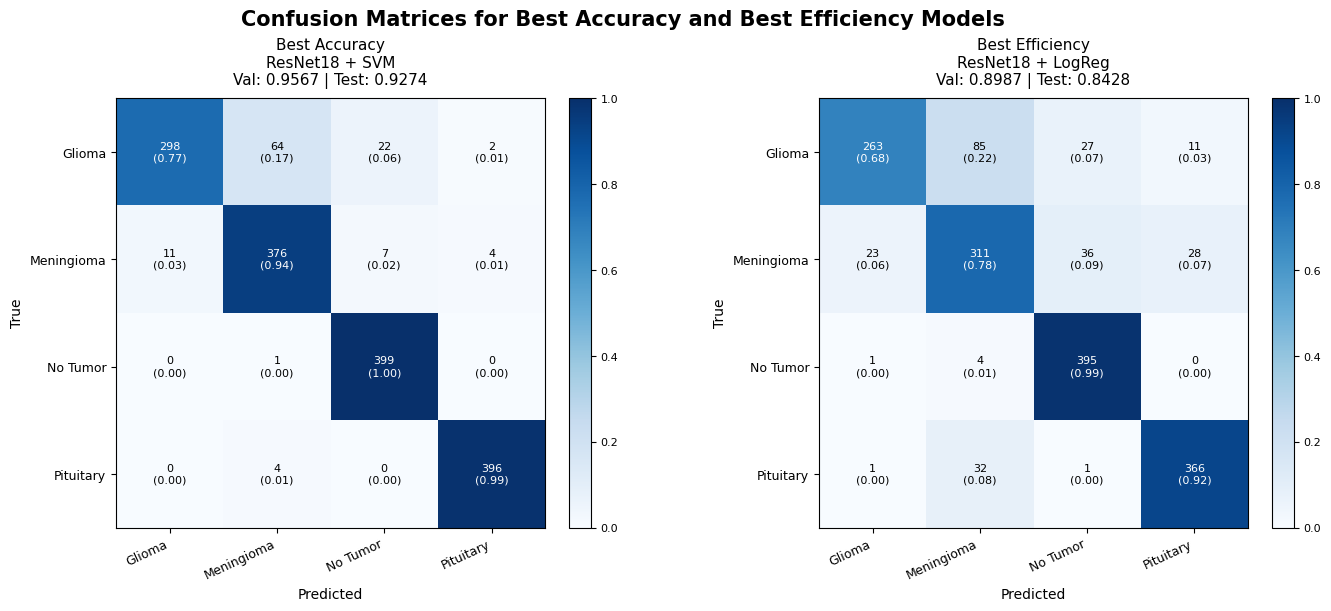

In [34]:
# Models to plot
selected_models = [('Best Accuracy', best_acc_key), ('Best Efficiency', best_eff_key)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
fig.suptitle('Confusion Matrices for Best Accuracy and Best Efficiency Models', fontsize=15,
             fontweight='bold')

for ax, (label, key) in zip(axes, selected_models):
    family, clf_name = key
    (best_feat_name, _), best_info = best_by_group[key]

    y_pred = best_info['y_pred']
    val_acc = best_info['val_acc']
    test_acc = best_info['test_acc']

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    # plot row-normalized confusion matrix via vmin, vmax = 0,1
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)

    ax.set_xticks(range(len(class_labels)))
    ax.set_xticklabels(class_labels, rotation=25, ha='right', fontsize=9)
    ax.set_yticks(range(len(class_labels)))
    ax.set_yticklabels(class_labels, fontsize=9)

    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True', fontsize=10)

    ax.set_title(f'{label}\n{family_display_name(family)} + {clf_name}\n'
        f'Val: {val_acc:.4f} | Test: {test_acc:.4f}',
                 fontsize=11, pad=10)

    # add counts + normalized values inside each cell
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f'{cm[i, j]}\n({cm_norm[i, j]:.2f})',
                    ha='center', va='center', fontsize=8,
                    color='white' if cm_norm[i, j] > 0.6 else 'black')

    # include colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)
plt.show()
